In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import awkward as ak
import fastjet as fj
import matplotlib.pyplot as plt
import numpy as np
import uproot
from tqdm import tqdm

In [3]:
# from particle import PDGID
# def pid_to_class(pid: int) -> int:
#     if abs(pid) == 11:
#         return 1
#     if abs(pid) == 13:
#         return 2
#     p = PDGID(pid)
#     if p.is_hadron:
#         if p.charge != 0:
#             return 0
#         return 3
#      return 4

def pid_to_class(pid: np.array) -> np.array:
    abs_pid = np.abs(pid)
    part_class = np.ones_like(abs_pid, dtype=int) * 5
    part_class[abs_pid == 11] = 1
    part_class[abs_pid == 13] = 2
    part_class[abs_pid == 22] = 3
    part_class[np.isin(abs_pid, [211, 321, 999211, 2212])] = 0
    part_class[np.isin(abs_pid, [111, 130, 310, 2112])] = 4
    return part_class

In [4]:
def load_raw_data(filepath, entry_stop=None):
    with uproot.open(
        filepath,
        num_workers=8,
    ) as f:
        data = {
            "pflow" : {},
            "truth" : {},
            "muons" : {},
            "electrons" : {}
        }
        var_list = ['pt', 'eta', 'phi', 'vx', 'vy', 'vz', 'pdgId']
        additional_vars = ['d0', 'd0Error', 'z0', 'z0Error', 'ip3d', 'ip3dError']
        pf_tree = f['pfcs/Events']
        for key in pf_tree.keys():
            array_names = [f"PFCand_{var}" for var in var_list + additional_vars]
            arrays = pf_tree.arrays(array_names, library="np", entry_stop=entry_stop)
            for var in var_list + additional_vars:
                    data['pflow'][var] = arrays[f"PFCand_{var}"]
            # if key.startswith("PFCand_"):
                # varname = key.split("_")[-1]
                # if varname in var_list + additional_vars:
                    # data['pflow'][key.split("_")[-1]] = pf_tree[key].array(library="np", entry_stop=entry_stop)
        gen_tree = f['gens/Events']
        for key in gen_tree.keys():
            array_names = [f"GenPart_{var}" for var in var_list]
            arrays = gen_tree.arrays(array_names, library="np", entry_stop=entry_stop)
            for var in var_list:
                data['truth'][var] = arrays[f"GenPart_{var}"]
            # if key.startswith("GenPart_"):
            #     varname = key.split("_")[-1]
            #     if varname in var_list:
            #         data['truth'][key.split("_")[-1]] = gen_tree[key].array(library="np", entry_stop=entry_stop)
        lepton_var_list = ['pfreliso03all', 'pfreliso04all']
        tree = f['mymuons/Events']
        for key in tree.keys():
            array_names = [f"muon_{var}" for var in lepton_var_list]
            arrays = tree.arrays(array_names, library="np", entry_stop=entry_stop)
            for var in lepton_var_list:
                data['muons'][var] = arrays[f"muon_{var}"]
            # if key.startswith("muon_"):
            #     data['muons'][key.split("_")[-1]] = tree[key].array(library="np", entry_stop=entry_stop)
        tree = f['myelectrons/Events']
        for key in tree.keys():
            array_names = [f"electron_{var}" for var in lepton_var_list]
            arrays = tree.arrays(array_names, library="np", entry_stop=entry_stop)
            for var in lepton_var_list:
                data['electrons'][var] = arrays[f"electron_{var}"]
            # if key.startswith("electron_"):
            #     data['electrons'][key.split("_")[-1]] = tree[key].array(library="np", entry_stop=entry_stop)
        for key in ['pflow', 'truth']:
            data[key]['class'] = np.array([
                pid_to_class(data[key]['pdgId'][i])
                for i in range(len(data[key]['pdgId']))
            ], dtype=object)
        data['eventNumber'] = f['events/Events']['event'].array(library='np', entry_stop=entry_stop)
        return data

In [5]:
def load_data(filepath, entry_stop=None, load_cms=False):
    with uproot.open(
        filepath,
        num_workers=8,
    ) as f:
        data = {
            "fastsim": {},
        }
        if load_cms:
            data["pflow"] = {}
            data["truth"] = {}
        tree = f[f"evt_tree"]
        for var in tree.keys():
            if not load_cms and ("pflow" in var or "truth" in var):
                continue
            arr = tree[var].array(library="np", entry_stop=entry_stop)
            if "pflow" in var:
                data["pflow"][var.replace("pflow_", "")] = arr
            elif "fastsim" in var:
                data["fastsim"][var.replace("fastsim_", "")] = arr
            elif "truth" in var:
                data["truth"][var.replace("truth_", "")] = arr
            else:
                data[var] = arr
    return data


def zero_neutral_vtx(data):
    for key in ["pflow", "fastsim"]:
        if key not in data:
            continue
        for i in range(len(data[key]["pt"])):
            part_class = data[key]["class"][i]
            data[key]["vx"][i][part_class > 2] = 0
            data[key]["vy"][i][part_class > 2] = 0
            data[key]["vz"][i][part_class > 2] = 0


def get_common_events(data_dict):
    goodEvents = np.array(
        list(
            set.intersection(
                *[set(data["eventNumber"].astype(int)) for data in data_dict.values()]
            )
        ),
        dtype=int,
    )
    return goodEvents


def filter_events(data_dict, n_events=None):
    goodEvents = get_common_events(data_dict)[:n_events]
    for key in data_dict.keys():
        idx_sorted = np.argsort(data_dict[key]["eventNumber"])
        idxs = np.argwhere(
            np.isin(data_dict[key]["eventNumber"][idx_sorted], goodEvents)
        ).flatten()
        for constituent in ["pflow", "fastsim", "truth", "muons", "electrons"]:
            if constituent not in data_dict[key]:
                continue
            for feat_name, value in data_dict[key][constituent].items():
                data_dict[key][constituent][feat_name] = value[idx_sorted][idxs]
        data_dict[key]["eventNumber"] = data_dict[key]["eventNumber"][idx_sorted][idxs]
    print(f"Filtered events: {len(goodEvents)}")


def load_sample(
    path_dict: dict,
    n_events: int = None,
):
    data_dict = {}

    for key, value in path_dict.items():
        key = key.split("_")[0] # Clean name
        if key == 'cms':
            data_dict[key] = load_raw_data(value, entry_stop=n_events)
        else:
            data_dict[key] = load_data(
                value, entry_stop=n_events, load_cms=True
            )
            zero_neutral_vtx(data_dict[key])
    filter_events(data_dict, n_events=n_events)

    return data_dict

In [6]:
samples_path_dict_noKnnLarge = {
    "ttbar": {
        "fm_path": "/storage/agrp/dmitrykl/fastsim/f_delphes/evaluation/fevt_paper_evals/ttbar_eval_combined_pt025_eta27_ghost_evt_double_LRFixTFCos_Deep5M_Flex_SinCos_noKnn_ext_66_dpm_40_49k_test_eta25Eval.root",
        "cms_path" : "/storage/agrp/dmitrykl/fastsim/f_delphes/data/full_event/raw_impact/MonteCarlo2011/Summer11LegDR/TTJets_MSDecays_central_TuneZ2_7TeV-madgraph-tauola/AODSIM/PU_S13_START53_LV6-v1/00000/000F3C2D-E7BA-E311-88FF-90E6BA0D09E8_poet.root"
    },
    "h4lep" : {
        "fm_path": "/storage/agrp/dmitrykl/fastsim/f_delphes/evaluation/fevt_paper_evals/h4lep_eval_combined_pt025_eta27_ghost_evt_double_LRFixTFCos_Deep5M_Flex_SinCos_noKnn_ext_66_dpm_40_49k_test_eta25Eval.root",
        "cms_path" : "/storage/agrp/dmitrykl/fastsim/f_delphes/data/full_event/raw_impact/MonteCarlo2011/Summer11LegDR/GluGluToHToZZTo4L_M-125_7TeV-minloHJJ-pythia6-tauola/AODSIM/PU_S13_START53_LV6-v1/10000/0E7024D1-4A92-E411-A05E-002354EF3BD2_poet.root"
    }
}

In [7]:
data = {}
for key, value in samples_path_dict_noKnnLarge.items():
    data[key] = load_sample(value, n_events=None)
    print(f"Loaded {key} sample")

Filtered events: 18214
Loaded ttbar sample
Filtered events: 11525
Loaded h4lep sample


In [8]:
def cut_eta_pt(data, pt_min=0, eta_max=2.5):
    pt = data['pt']
    eta = data['eta']
    for i in tqdm(range(len(pt))):
        mask = (pt[i] > pt_min) & (np.abs(eta[i]) < eta_max)
        for key in data.keys():
            data[key][i] = data[key][i][mask]
    return data

In [9]:
for key, value in data.items():
    value['cms']['pflow'] = cut_eta_pt(value['cms']['pflow'], pt_min=1, eta_max=2.7)
    value['cms']['truth'] = cut_eta_pt(value['cms']['truth'], pt_min=0.25, eta_max=2.7)

100%|██████████| 11525/11525 [00:00<00:00, 52239.62it/s]


In [10]:
def cut_pdgId(data):
    mask = []
    for el in data['pdgId']:
        quark_mask = np.abs(el) > 8
        boson_mask = np.isin(np.abs(el), [21, 23, 24, 25, 32, 33, 34,35,36,37], invert=True)
        mask.append(np.logical_and(quark_mask, boson_mask))
    for key in data.keys():
        for i in range(len(data[key])):
            data[key][i] = data[key][i][mask[i]]
    return data

In [11]:
for key, value in data.items():
    value['cms']['pflow'] = cut_pdgId(value['cms']['pflow'])
    value['cms']['truth'] = cut_pdgId(value['cms']['truth'])

In [12]:
def calculate_isolation_v3(pt, eta, phi, class_id, dr_cut=0.4, pt_cut = 0):

    mask = pt > pt_cut
    pt, eta, phi, class_id = pt[mask], eta[mask], phi[mask], class_id[mask]
    rho = 0
    area = 0
    lepton_mask = (class_id == 1) | (class_id == 2)
    ch_hadron_mask = class_id == 0
    neut_mask = (class_id == 3) # | (class_id == 4)
    phot_mask = class_id == 4
    # print(pt.shape, eta.shape, phi.shape, class_id.shape, rho, area)
    dEta = eta[:, None] - eta[None, :]
    dPhi = phi[:, None] - phi[None, :]
    dPhi = np.atan2(np.sin(dPhi), np.cos(dPhi))
    dR = np.sqrt(dEta**2 + dPhi**2)
    
    dR_mask_phot = dR < 0.3
    ch_pt_sum_phot = ((pt * dR_mask_phot) * ch_hadron_mask).sum(-1)
    neut_pt_sum_phot = ((pt * dR_mask_phot) * neut_mask).sum(-1)
    iso_score_phot = (ch_pt_sum_phot + np.maximum(0, neut_pt_sum_phot - rho * area)) / pt
    iso_score_phot[~phot_mask] = 1000

    rho = 0
    area = 0
    iso_phot_mask = (iso_score_phot < 1)
    iso_phot_mask_close = ~(iso_phot_mask & (pt > 2) & (dR < 0.07))
    iso_phot_mask_far = ~(iso_phot_mask & (pt > 4) & (dR >= 0.07) & (dR < 0.5))
    dR_mask = dR < dr_cut
    pt_mat = pt
    ch_pt_sum = ((pt_mat * (pt_mat > 1) * dR_mask) * ch_hadron_mask).sum(-1)
    neut_mask = neut_mask # | (iso_phot_mask_close & phot_mask) | (iso_phot_mask_far & phot_mask)
    phot_mask = (iso_phot_mask_close & phot_mask) | (iso_phot_mask_far & phot_mask)
    neut_pt_sum = ((pt_mat * dR_mask) * neut_mask).sum(-1)
    phot_pt_sum = ((pt_mat * dR_mask) * phot_mask).sum(-1)
    iso_score = (ch_pt_sum + np.maximum(0, neut_pt_sum + phot_pt_sum - rho * area)) / pt
    iso_score[~lepton_mask] = -1000

    return iso_score, ch_pt_sum, neut_pt_sum, phot_pt_sum

In [13]:
for sample, sample_data in data.items():
    for key, value in sample_data.items():
        for collection in ['pflow', 'fastsim']:
            if collection not in value:
                continue
            isolation_scores = []
            for i in tqdm(range(len(value[collection]['pt']))):
                iso_score, ch_pt_sum, neut_pt_sum, phot_pt_sum = calculate_isolation_v3(
                    value[collection]['pt'][i],
                    value[collection]['eta'][i],
                    value[collection]['phi'][i],
                    value[collection]['class'][i],
                )
                isolation_scores.append(iso_score)
            value[collection]['iso_score'] = isolation_scores

  0%|          | 0/18214 [00:00<?, ?it/s]

100%|██████████| 11525/11525 [00:02<00:00, 5391.49it/s]


In [14]:
def extract_iso(data, pt_cut = 0, class_mask = lambda x: x < 3):
    muon_iso = []
    isolation_scores = data['iso_score']
    for i in range(len(isolation_scores)):
        mask = (data['pt'][i] > pt_cut) & (class_mask(data['class'][i]))
        muon_iso.append(isolation_scores[i][mask])
    return muon_iso

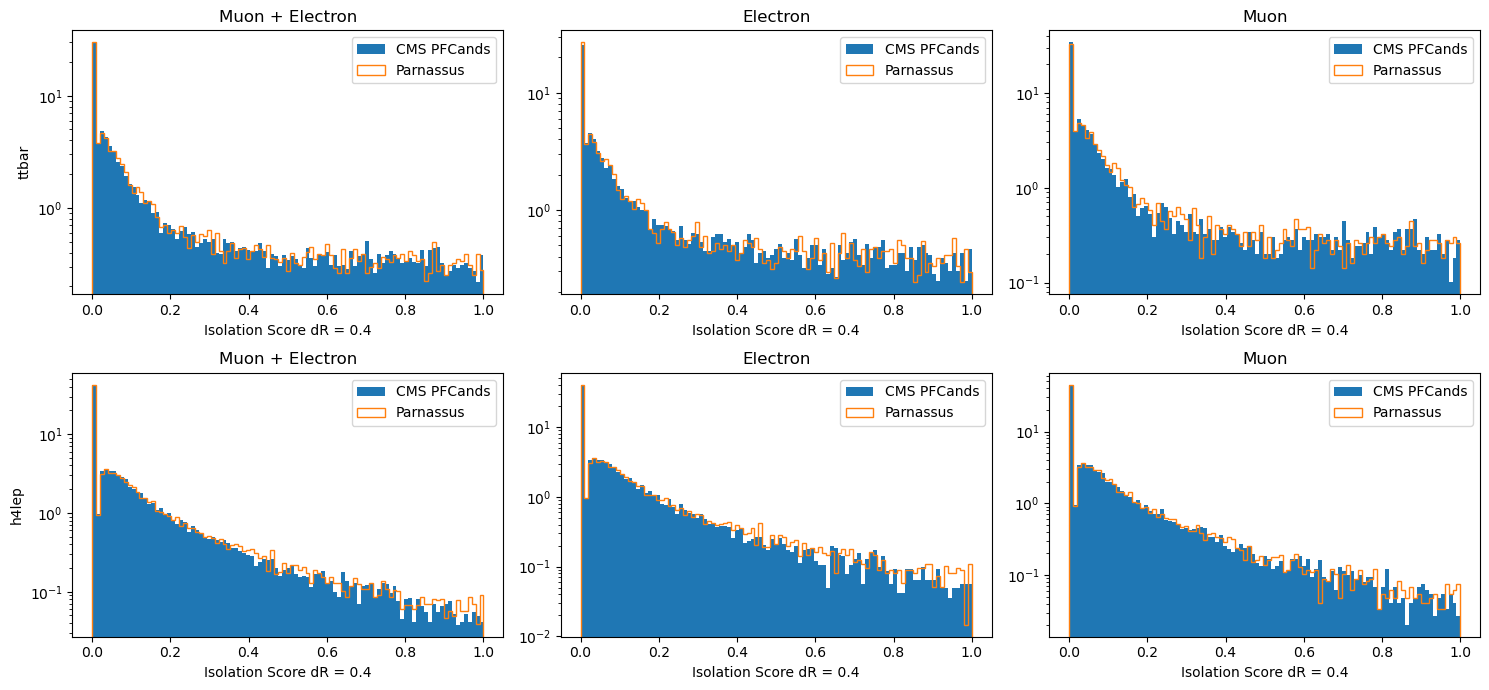

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
bins = np.linspace(0, 1, 100)
masks = [
    lambda x: (x == 1) | (x == 2),
    lambda x: x == 1,
    lambda x: x == 2,
]
labels = [
    "Muon + Electron",
    "Electron",
    "Muon",
]
for i, (sample, value) in enumerate(data.items()):
    for j, (mask, label) in enumerate(zip(masks, labels)):
        ax[i][j].hist(
            np.concatenate(extract_iso(value['cms']['pflow'], pt_cut=3, class_mask=mask)),
            bins=bins,
            histtype='stepfilled',
            label="CMS PFCands",
            density=True,
        )
        ax[i][j].hist(
            np.concatenate(extract_iso(value['fm']['fastsim'], pt_cut=3, class_mask=mask)),
            bins=bins,
            histtype='step',
            label='Parnassus',
            density=True,
        )
        ax[i][j].set_title(label)
        ax[i][j].legend()
        ax[i][j].set_xlabel("Isolation Score dR = 0.4")
        ax[i][j].set_yscale('log')
    ax[i][0].set_ylabel(sample)
fig.tight_layout()
plt.show()

In [32]:
from res_map_v2 import d0_eta_bins, d0_pt_bins_charged, d0_pt_bins_muons, d0_funclist_charged, d0_funclist_muons
from res_map_v2 import z0_pt_bins_charged, z0_funclist_charged, z0_funclist_muons, z0_pt_bins_muons

In [17]:
z0_pt_bins_muons = np.array([
        0.1823,
    0.2227,
    0.2720,
    0.3323,
    0.4060,
    0.4959,
    0.6058,
    0.7401,
    0.9041,
    1.1044,
    1.3492,
    1.6481,
    2.0134,
    2.4595,
    3.0045,
    3.6703,
    4.4837,
    5.4772,
    6.6910,
    8.1737,
    9.9849,
    12.1976,
    14.9005,
    18.2024,
    22.2360,
    27.1635,
    33.1828,
    40.5360,
    49.5187,
    60.4919,
    73.8967,
    90.2720,
    110.2760,
    134.7130,
    1e6
])

In [18]:
z0_pt_bins_charged = np.append(z0_pt_bins_charged, 1e6)

In [19]:
# np.interp()

In [20]:
from scipy.interpolate import CubicSpline

In [21]:
def get_d0Error(pt, eta, pt_bins, funclist):
    error = 0
    for i, (left_eta, right_eta) in enumerate(zip(d0_eta_bins[:-1], d0_eta_bins[1:])):
        start_ = i * (len(pt_bins) - 1)
        end_ = (i + 1) * (len(pt_bins) - 1)
        # spline = CubicSpline(pt_bins[1:], funclist[start_:end_])
        error += (np.abs(eta) >= left_eta) * (np.abs(eta) < right_eta) * \
                np.interp(pt, pt_bins[1:], funclist[start_:end_]) * (1 + 2 * (1 - np.random.power(3, size=pt.shape[0])))
    return error

(array([2.79588235, 2.15462493, 1.68060745, 1.25378651, 0.94906098,
        0.6484395 , 0.42169088, 0.23290469, 0.10978327, 0.01333815]),
 array([1.10094181e-06, 9.74658602e-02, 1.94930619e-01, 2.92395379e-01,
        3.89860138e-01, 4.87324897e-01, 5.84789656e-01, 6.82254415e-01,
        7.79719175e-01, 8.77183934e-01, 9.74648693e-01]),
 <BarContainer object of 10 artists>)

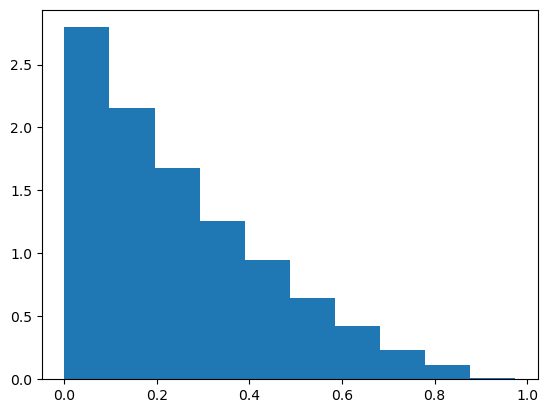

In [22]:
plt.hist(
    1 - np.random.power(3, size=10000),
    density=True
)

In [23]:
def split_array_into_chunks(array, chunk_lengths):
    """Split a 1D array into chunks of specified lengths.
    
    Args:
        array: numpy array to split
        chunk_lengths: list/array of desired chunk lengths
    
    Returns:
        list of numpy arrays with specified lengths
    """
    # Verify total length matches
    if sum(chunk_lengths) != len(array):
        raise ValueError("Sum of chunk lengths must equal array length")
    
    # Calculate split indices
    split_indices = np.cumsum(chunk_lengths)[:-1]
    
    # Split array into chunks
    return np.split(array, split_indices)

In [24]:
def get_d0(vx, vy, phi, pv_x = None, pv_y = None):
    if pv_x is not None and pv_y is not None:
        vx = vx - pv_x
        vy = vy - pv_y
    d0 = -vx * np.sin(phi) + vy * np.cos(phi)
    return d0

def get_z0(vz, eta, d0, pv_z = None):
    if pv_z is not None:
        vz = vz - pv_z
    z0 = vz - np.tan(eta) * d0
    return z0

In [29]:
for sample, sample_data in data.items():
    for key, value in sample_data.items():
        for var in ['vx', 'vy', 'vz']:
            pv = []
            for i in range(len(value['truth'][var])):
                unique, counts = np.unique(
                    value['truth'][var][i],
                    return_counts=True
                )
                pv.append(
                    unique[np.argmax(counts)]
                )
            value['pv_' + var[1]] = np.array(pv)
    # value['pv_x'] = np.array([el.mean() for el in value['truth']['vx']])
    # value['pv_y'] = np.array([el.mean() for el in value['truth']['vy']])
    # value['pv_z'] = np.array([el.mean() for el in value['truth']['vz']])

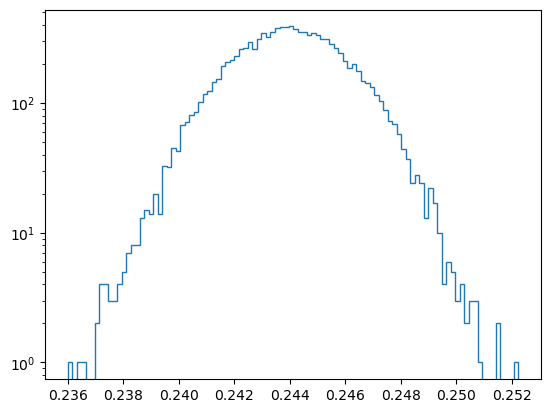

In [26]:
plt.hist(
    data['h4lep']['cms']['pv_x'],
    histtype='step',
    bins=100
)
plt.yscale('log')
plt.show()

In [33]:
def calculate_ip_params(data, pv_x, pv_y, pv_z, postfix = ""):
    vx, vy, vz = data['vx'], data['vy'], data['vz']
    pt, phi, eta = data['pt'], data['phi'], data['eta']
    class_ = data['class']
    d0_all = []
    z0_all = []
    d0Error_all = []
    z0Error_all = []
    for i in tqdm(range(len(pt))):
        d0 = get_d0(vx[i], vy[i], phi[i], pv_x[i], pv_y[i])
        z0 = get_z0(vz[i], eta[i], d0, pv_z[i])
        d0Error = np.ones_like(d0) * -999
        d0Error[class_[i] < 3] = get_d0Error(
            pt[i][class_[i] < 3],
            eta[i][class_[i] < 3],
            d0_pt_bins_charged,
            d0_funclist_charged,
        ) / 10 / 1e3
        d0Error[class_[i] == 2] = get_d0Error(
            pt[i][class_[i] == 2],
            eta[i][class_[i] == 2],
            d0_pt_bins_muons,
            d0_funclist_muons,
        ) / 10
        z0Error = np.ones_like(z0) * -999
        z0Error[class_[i] < 3] = get_d0Error(
            pt[i][class_[i] < 3],
            eta[i][class_[i] < 3],
            z0_pt_bins_charged,
            z0_funclist_charged,
        ) / 10 / 1e3
        # z0Error[class_[i] == 2] = get_d0Error(
        #     pt[i][class_[i] == 2],
        #     eta[i][class_[i] == 2],
        #     z0_pt_bins_muons,
        #     z0_funclist_muons,
        # ) / 10 / 1e3
        d0_all.append(d0)
        z0_all.append(z0)
        d0Error_all.append(d0Error)
        z0Error_all.append(z0Error)
    data['d0' + postfix] = d0_all
    data['z0' + postfix] = z0_all
    data['d0Error' + postfix] = d0Error_all
    data['z0Error' + postfix] = z0Error_all



In [34]:
for sample, sample_data in data.items():
    calculate_ip_params(
        sample_data['fm']['fastsim'],
        sample_data['fm']['pv_x'],
        sample_data['fm']['pv_y'],
        sample_data['fm']['pv_z'],
    )

100%|██████████| 11525/11525 [00:02<00:00, 5166.39it/s]


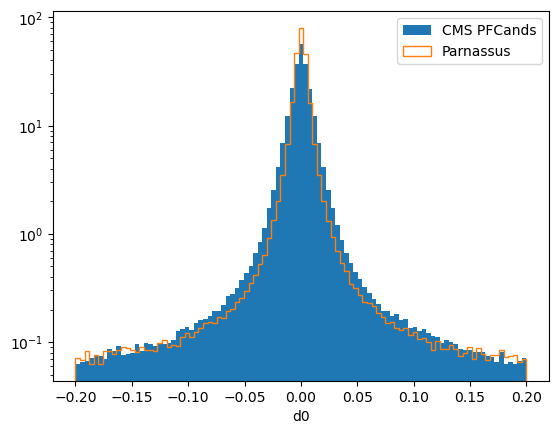

In [ ]:
plt.hist(np.concatenate(sample_data['cms']['pflow']['d0'])[np.concatenate(sample_data['cms']['pflow']['d0']) > -900], bins=np.linspace(-0.2, 0.2, 100), histtype='stepfilled', label='CMS PFCands', density=True)
plt.hist(np.concatenate(sample_data['fm']['fastsim']['d0'])[np.concatenate(sample_data['fm']['fastsim']['class']) < 3], bins=np.linspace(-0.2, 0.2, 100), histtype='step', label='Parnassus', density=True)
plt.xlabel('d0')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
calculate_ip_params(
    data['cms']['pflow'],
    data['cms']['pv_x'],
    data['cms']['pv_y'],
    data['cms']['pv_z'],
    postfix="My"
)

100%|██████████| 18214/18214 [00:01<00:00, 10206.12it/s]


In [35]:
def draw_sample(sample_data: str, pt_cut = 0):
    fig, ax = plt.subplots(3, 3, figsize=(15, 10))
    bins = {
        'd0' : [
            np.linspace(-0.1, 0.1, 100),
            np.linspace(-0.1, 0.3, 100),
            np.linspace(-4, 4, 100),
        ],
        'z0' : [
            np.linspace(-1, 1, 100),
            np.linspace(-0.1, 0.3, 100),
            np.linspace(-4, 4, 100),
        ],
        'ip3d' : [
            np.linspace(0, 0.25, 100),
            np.linspace(0, 4, 100),
            np.linspace(0, 20, 100),
        ],
    }
    labels = ['d0', 'z0', 'ip3d']
    for i, label in enumerate(labels):
        for key, value in sample_data.items():
            if key == "fm":
                if label == 'ip3d':
                    var = np.sqrt(
                        (1.5 * np.concatenate(value['fastsim']['d0']))**2 +
                        (np.concatenate(value['fastsim']['z0']))**2
                    )
                    varError = np.sqrt(
                        np.concatenate(value['fastsim']['d0Error'])**2 +
                        (np.concatenate(value['fastsim']['z0Error']))**2
                    )
                else:
                    var = np.concatenate(value['fastsim'][label])
                    if label == 'd0':
                        var = var * 1.5
                    varError = np.concatenate(value['fastsim'][label + "Error"]) if label + "Error" in value['fastsim'] else np.ones_like(var)
                    if label == 'z0':
                        # var = var / 1.5
                        varError = varError
                mask = (np.concatenate(value['fastsim']['class']) < 3) & (np.concatenate(value['fastsim']['pt']) > pt_cut)
                # value = data['cms']
                # if label == 'ip3d':
                #     var = np.sqrt(
                #         np.concatenate(value['pflow']['d0My'])**2 +
                #         np.concatenate(value['pflow']['z0My'])**2
                #     )
                # else:
                #     var = np.concatenate(value['pflow'][label + "My"])
                # varError = np.concatenate(value['pflow'][label + "ErrorMy"]) if label + "ErrorMy" in value['pflow'] else np.ones_like(var)
                # mask = np.concatenate(value['pflow']['class']) < 3
            else: 
                if label == 'ip3d':
                    var = np.sqrt(
                        np.concatenate(value['pflow']['d0'])**2 +
                        np.concatenate(value['pflow']['z0'])**2
                    )
                    varError = np.sqrt(
                        np.concatenate(value['pflow']['d0Error'])**2 +
                        np.concatenate(value['pflow']['z0Error'])**2
                    )
                else:
                    var = np.concatenate(value['pflow'][label + ""])
                    varError = np.concatenate(value['pflow'][label + "Error"]) if label + "Error" in value['pflow'] else np.ones_like(var)
                # varError = np.clip(varError, 0, 0.2)
                mask = (np.concatenate(value['pflow']['class']) < 3) & (np.concatenate(value['pflow']['pt']) > pt_cut)
            ax[0, i].hist(var[mask], label=key, histtype='step', density=True, bins=bins[label][0])
            ax[1, i].hist(varError[mask], label=key, histtype='step', density=True, bins=bins[label][1])
            ax[2, i].hist((var[mask] / varError[mask]), label=key, histtype='step', density=True, bins=bins[label][2])
        ax[0, i].set_title(label)
        ax[1, i].set_title(label + "Error")
        ax[2, i].set_title(label + " / " + label + "Error")
        for j in range(3):
            ax[j, i].legend()
            ax[j, i].set_yscale('log')
            ax[j, i].set_xlabel(label)
            ax[j, i].set_ylabel('Density')
            ax[j, i].grid()
    fig.tight_layout()
    fig.show()

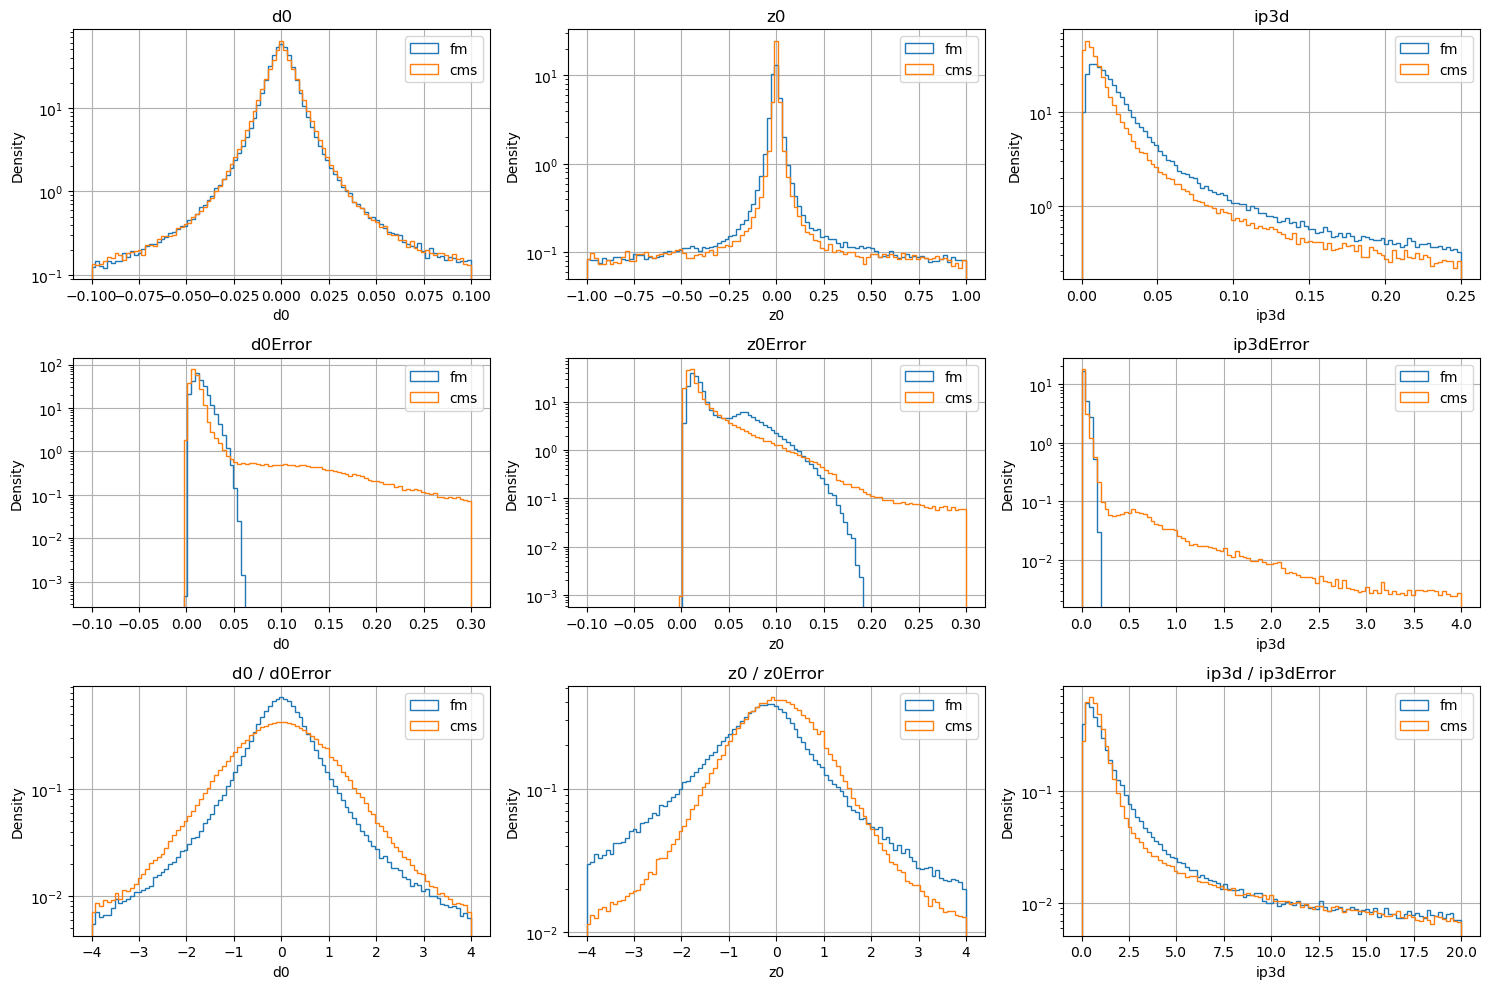

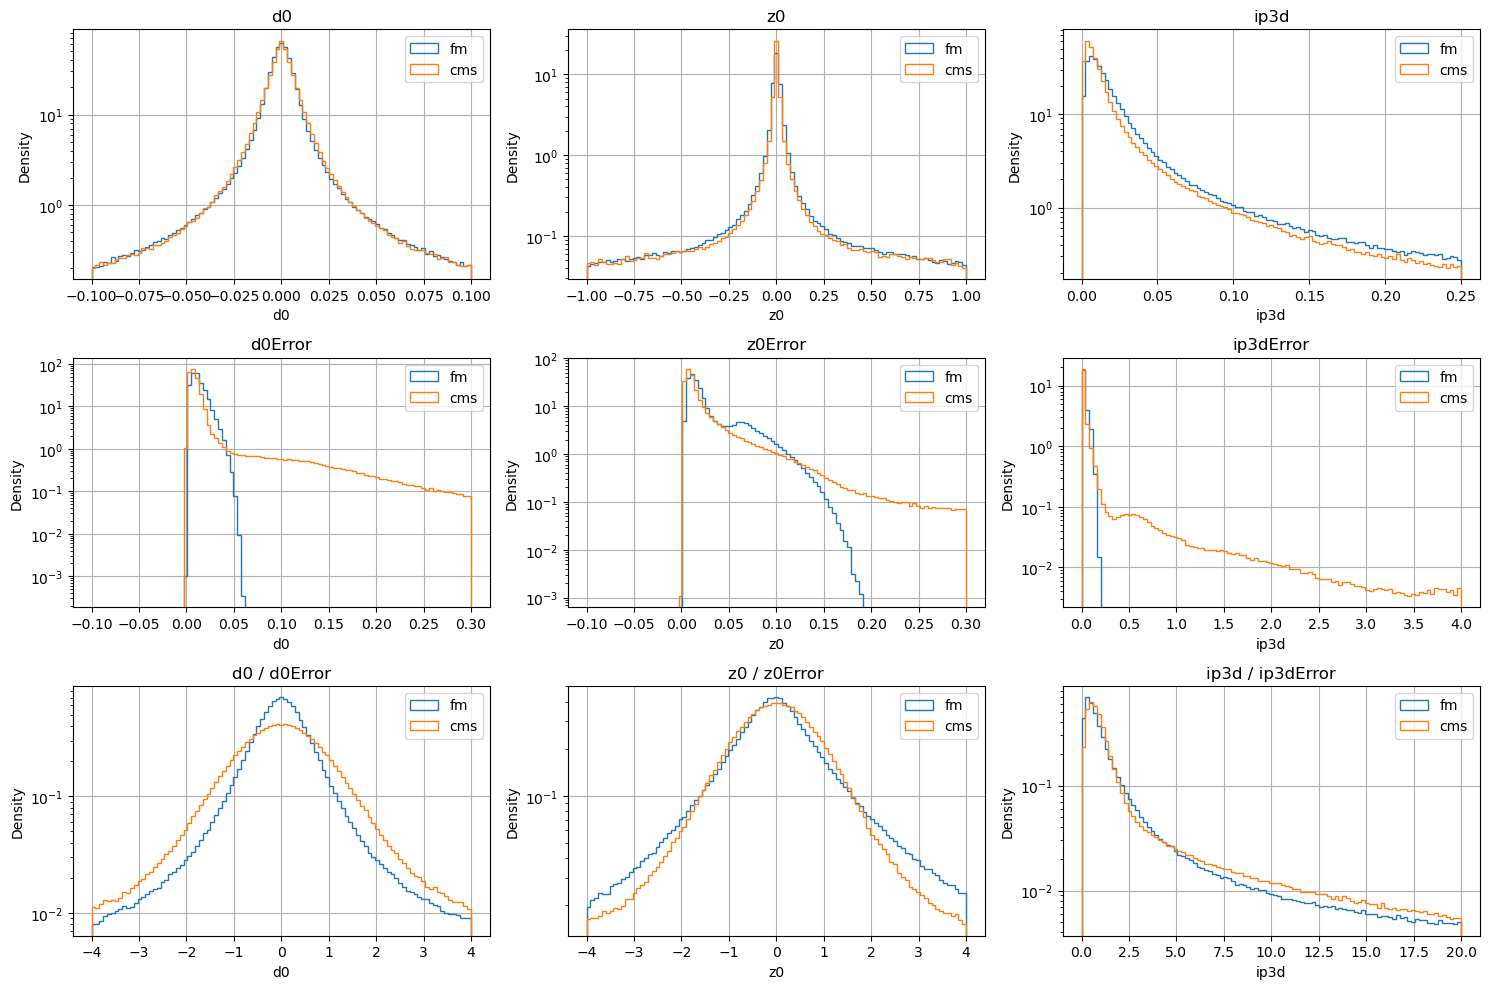

In [36]:
draw_sample(data['h4lep'], pt_cut=1)
draw_sample(data['ttbar'], pt_cut=1)

In [ ]:
n_charged_cms = []
n_charged_fastsim = []
for i in tqdm(range(len(data['cms']['pflow']['pt']))):
    n_charged_cms.append(np.sum(data['cms']['pflow']['class'][i] < 3))
    n_charged_fastsim.append(np.sum(data['fm']['fastsim']['class'][i] < 3))

100%|██████████| 18214/18214 [00:00<00:00, 101053.80it/s]


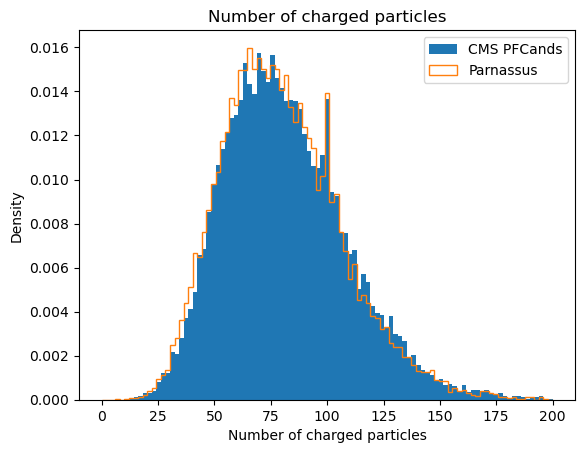

In [ ]:
plt.hist(
    n_charged_cms,
    bins=np.linspace(0, 200, 100),
    histtype='stepfilled',
    label="CMS PFCands",
    density=True,
)
plt.hist(
    n_charged_fastsim,
    bins=np.linspace(0, 200, 100),
    histtype='step',
    label='Parnassus',
    density=True,
)
plt.title("Number of charged particles")
plt.xlabel("Number of charged particles")
plt.ylabel("Density")
plt.legend()
plt.show()

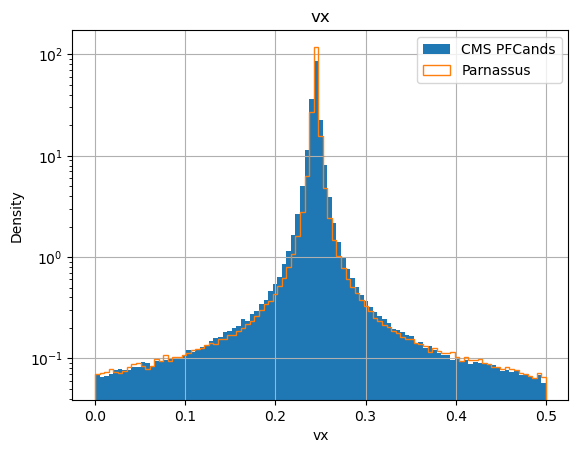

In [ ]:
plt.hist(
    np.concatenate(data['cms']['pflow']['vx'])[np.concatenate(data['cms']['pflow']['class']) < 3],
    bins=np.linspace(0, 0.5, 100),
    histtype='stepfilled',
    label="CMS PFCands",
    density=True,
)
plt.hist(
    np.concatenate(data['fm']['fastsim']['vx'])[np.concatenate(data['fm']['fastsim']['class']) < 3],
    bins=np.linspace(0, 0.5, 100),
    histtype='step',
    label='Parnassus',
    density=True,
)
plt.yscale('log')
plt.xlabel("vx")
plt.ylabel("Density")
plt.title("vx")
plt.legend()
plt.grid()
plt.show()

In [ ]:
pt_pfcs = np.concatenate(data['cms']['pflow']['pt'])
class_pfcs = np.concatenate(data['cms']['pflow']['class'])
eta_pfcs = np.concatenate(data['cms']['pflow']['eta'])
d0_pfcs = np.concatenate(data['cms']['pflow']['d0'])
d0Error_pfcs = np.concatenate(data['cms']['pflow']['d0Error'])

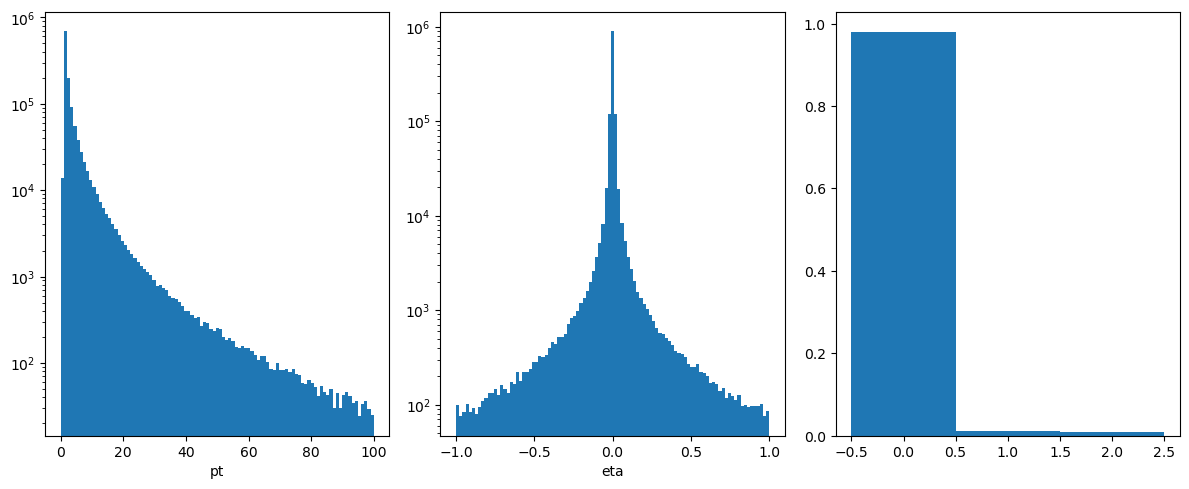

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].hist(
    pt_pfcs[(class_pfcs < 3) & (d0Error_pfcs < 0.02)],
    bins=np.linspace(0, 100, 100)
)
ax[1].hist(
    d0_pfcs[(class_pfcs < 3) & (d0Error_pfcs < 0.02)],
    bins=np.linspace(-1, 1, 100)
)
ax[2].hist(
    class_pfcs[(class_pfcs < 3) & (d0Error_pfcs < 0.02)],
    bins=np.linspace(0, 3, 4) - 0.5,
    density=True,
)
for i in range(2):
    ax[i].set_xlabel(['pt', 'eta'][i])
    ax[i].set_yscale('log')
fig.tight_layout()
plt.show()

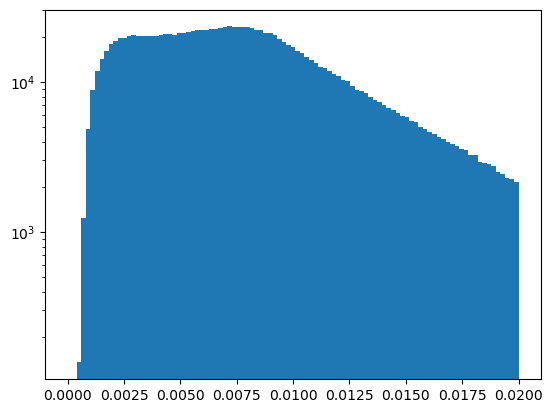

In [ ]:
plt.hist(
    d0Error_pfcs[class_pfcs < 3],
    bins=np.linspace(0, 0.02, 100),
    histtype='stepfilled',
)
plt.yscale('log')
plt.show()

In [ ]:
error_mean = []
error_std = []
for left_eta, right_eta in zip(
    d0_eta_bins[:-1],
    d0_eta_bins[1:],
):
    error_mean.append([])
    error_std.append([])
    for left_bin, right_bin in zip(
        d0_pt_bins_charged[:-1],
        d0_pt_bins_charged[1:],
    ):
        mask = (eta_pfcs > left_eta) & (eta_pfcs < right_eta) & \
            (pt_pfcs > left_bin) & (pt_pfcs < right_bin) & \
            (class_pfcs < 3)
        error_mean[-1].append((1000 * d0Error_pfcs)[mask].mean())
        # error_std[-1].append((1000 * d0Error_pfcs)[mask].std())
    error_mean[-1] = np.array(error_mean[-1])
    # error_std[-1] = np.array(error_std[-1])


NameError: name 'eta_pfcs' is not defined

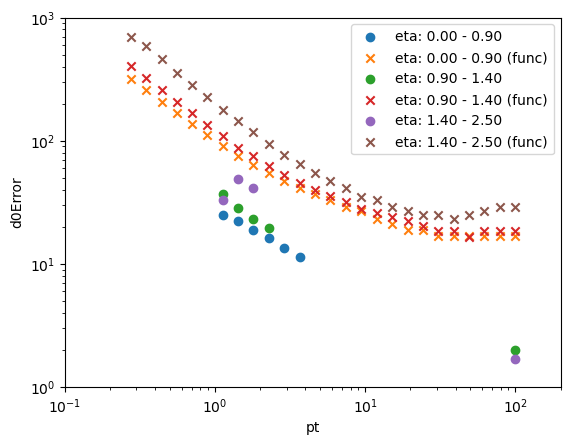

In [ ]:
for i, (left_eta, right_eta) in enumerate(zip(d0_eta_bins[:-1], d0_eta_bins[1:])):

    plt.scatter(
        d0_pt_bins_charged[1:],
        error_mean[i],
        label=f"eta: {left_eta:.2f} - {right_eta:.2f}",
    )
    plt.scatter(
        d0_pt_bins_charged[1:],
        d0_funclist_charged[i * (len(d0_pt_bins_charged) - 1):(i + 1) * (len(d0_pt_bins_charged) - 1)],
        label=f"eta: {left_eta:.2f} - {right_eta:.2f} (func)",
        marker='x',
    )
plt.xlim(0.1, 200)
plt.ylim(1, 1000)
plt.xlabel("pt")
plt.ylabel("d0Error")
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.show()